## Importing filters

In [2]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"
global_min = np.inf
global_max = -np.inf

for fname in os.listdir(filter_folder):
    if fname.endswith(".txt"):

        filepath = os.path.join(filter_folder, fname)
        data = np.loadtxt(filepath)

        lam_min = data[:, 0].min()
        lam_max = data[:, 0].max()

        global_min = min(global_min, lam_min)
        global_max = max(global_max, lam_max)

        print(f"{fname:20s}  {lam_min:.0f} – {lam_max:.0f} Å")

print("\nOverall wavelength coverage:")
print(f"{global_min:.0f} – {global_max:.0f} Å")

HST_ACS_WFC_F435W.txt  3526 – 4979 Å
HST_ACS_WFC_F606W.txt  4569 – 7283 Å
HST_ACS_WFC_F814W.txt  6738 – 9778 Å
HST_WFC3_IR_F105W.txt  8650 – 12250 Å
HST_WFC3_IR_F125W.txt  10640 – 14390 Å
HST_WFC3_IR_F140W.txt  11370 – 16450 Å
HST_WFC3_IR_F160W.txt  13664 – 17205 Å
JWST_NIRCam_F090W.txt  7836 – 10356 Å
JWST_NIRCam_F115W.txt  9892 – 13282 Å
JWST_NIRCam_F150W.txt  12798 – 17238 Å
JWST_NIRCam_F200W.txt  16904 – 22984 Å
JWST_NIRCam_F277W.txt  23371 – 33015 Å
JWST_NIRCam_F356W.txt  29930 – 42294 Å
JWST_NIRCam_F410M.txt  36740 – 45226 Å
JWST_NIRCam_F444W.txt  37132 – 50996 Å

Overall wavelength coverage:
3526 – 50996 Å


In [3]:
import os
import numpy as np

filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"

filter_files = [
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
]

filter_files.sort()

print(filter_files)

['D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F435W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F606W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_ACS_WFC_F814W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F105W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star Formation Histories\\star-formation-histories\\Data\\starburst_filters\\HST_WFC3_IR_F125W.txt', 'D:\\Users\\Abigail Crowther\\Desktop\\Uni\\Year 4\\MPhys Projects\\Semester 2 - Star For

## Visualising filters

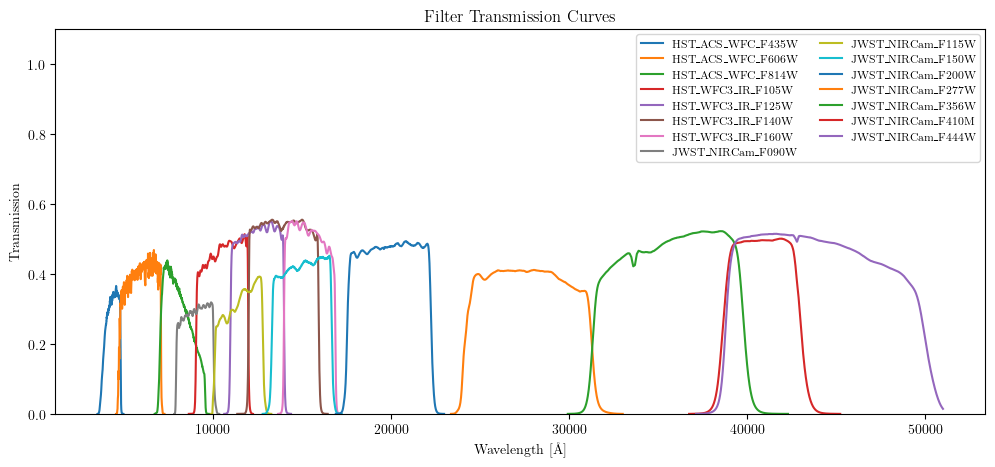

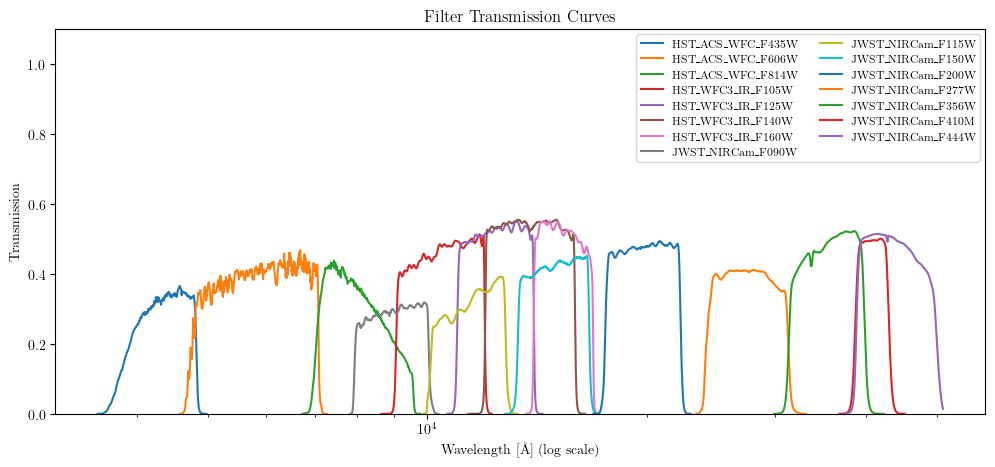

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}"
})

plt.figure(figsize=(12,5))

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]          # wavelength in Å
    transmission = filt_data[:,1]  # 0-1 transmission
    filt_label = os.path.splitext(os.path.basename(ffile))[0]
    plt.plot(wave, transmission, label=filt_label)

plt.xlabel("Wavelength [Å]")
plt.ylabel("Transmission")
plt.title("Filter Transmission Curves")
plt.legend(fontsize=8, ncol=2)
plt.xscale('linear')
plt.ylim(0,1.1)
plt.show()

plt.figure(figsize=(12,5))

for ffile in filter_files:
    filt_data = np.loadtxt(ffile)
    wave = filt_data[:,0]          # wavelength in Å
    transmission = filt_data[:,1]  # 0-1 transmission
    filt_label = os.path.splitext(os.path.basename(ffile))[0]
    plt.plot(wave, transmission, label=filt_label)

plt.xscale('log')
plt.xlabel("Wavelength [Å] (log scale)")
plt.ylabel("Transmission")
plt.title("Filter Transmission Curves")
plt.legend(fontsize=8, ncol=2)
plt.ylim(0,1.1)
plt.show()

## Setting age ranges

In [5]:

import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200, 1100, 100)

years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


## Defining dust and nebula

In [6]:
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 2. #multiplies Av - extra dust for young stars

nebular = {}   #nebular emission component
nebular["logU"] = -3.   #log_10(ionization parameter)

## Photometry for all ages

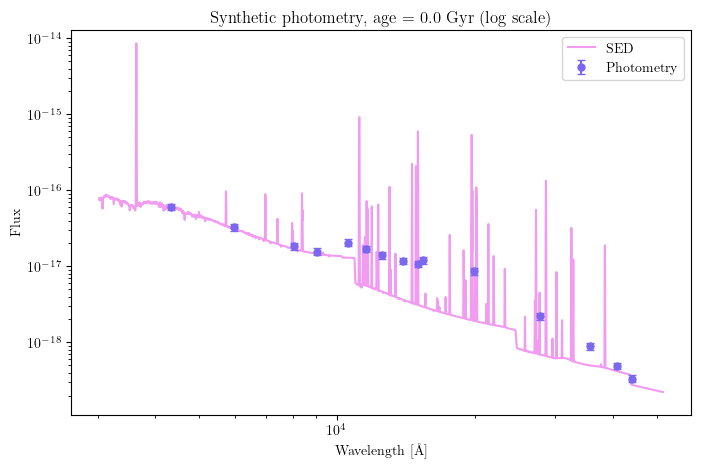

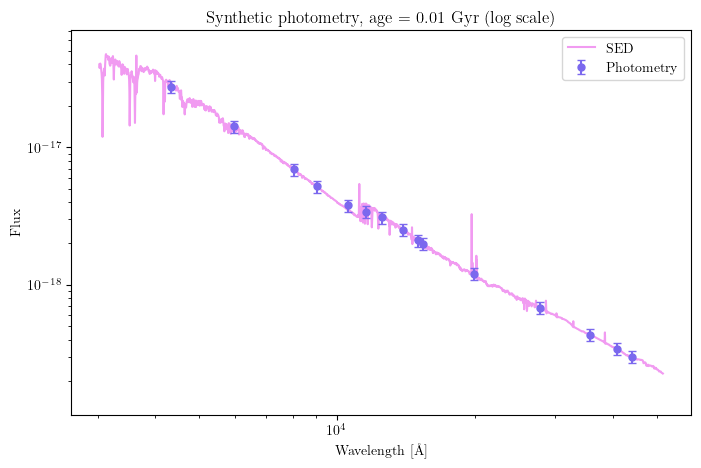

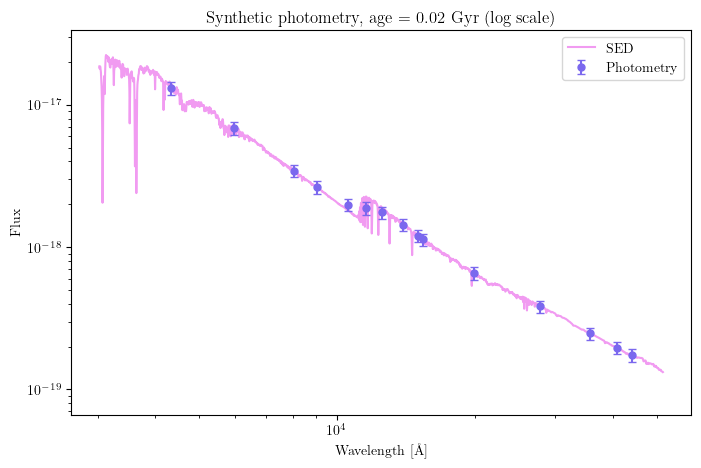

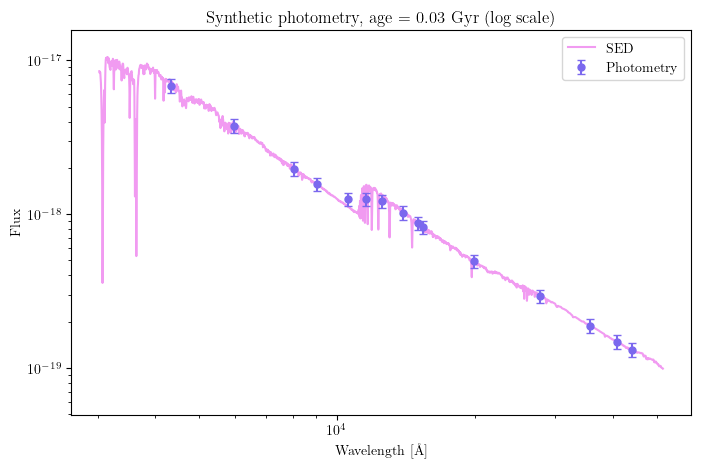

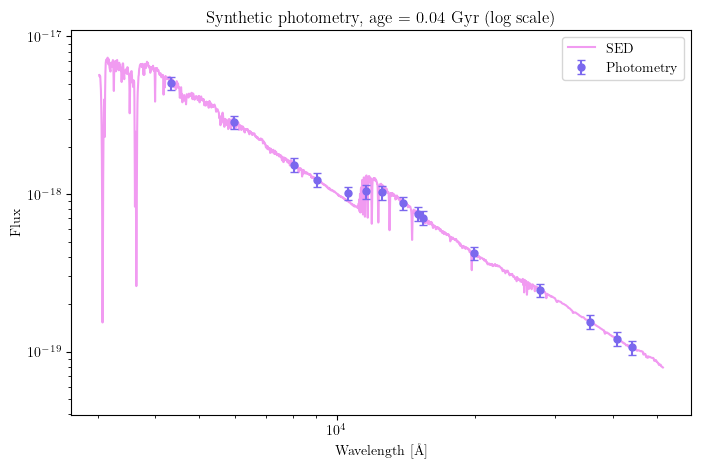

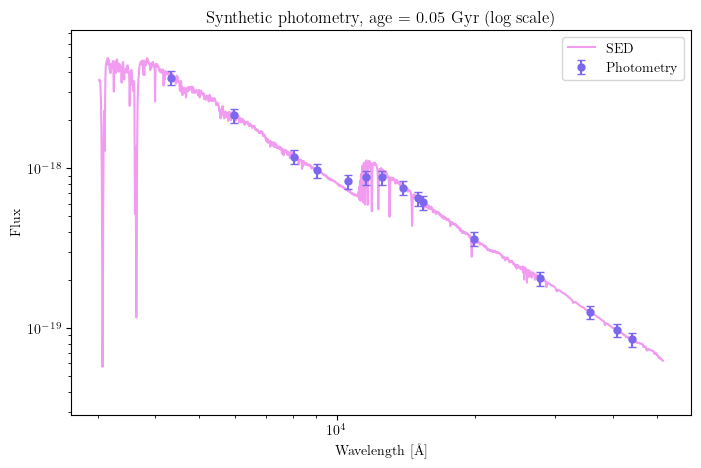

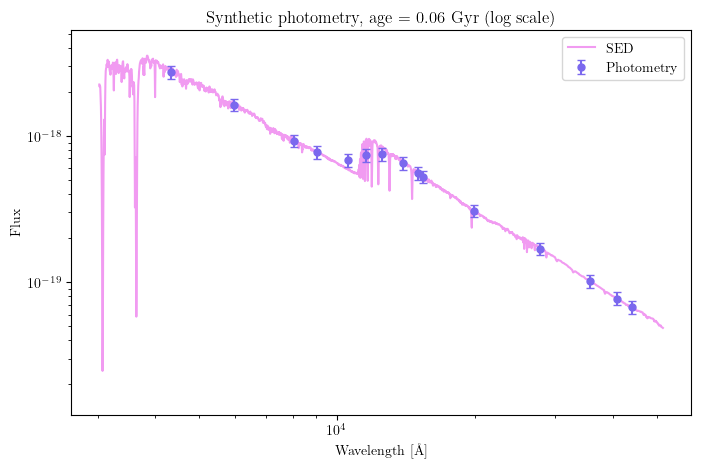

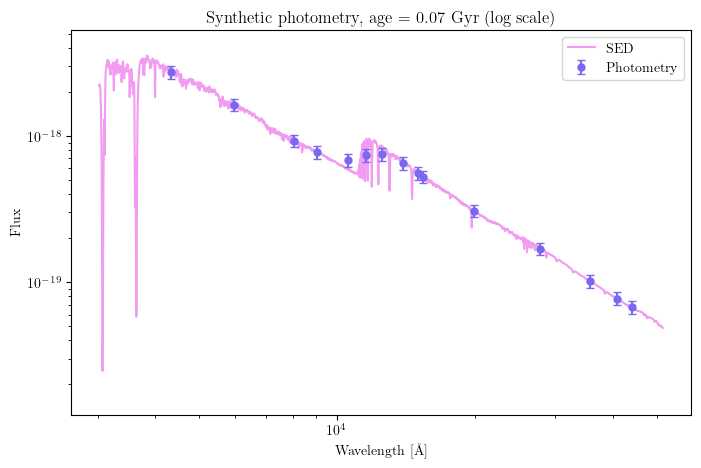

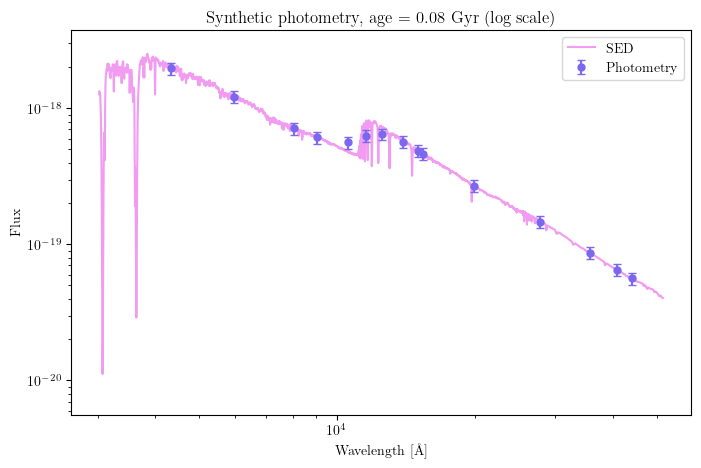

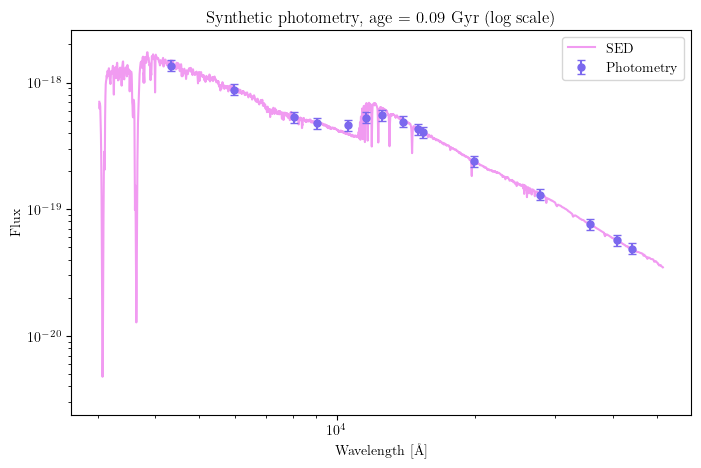

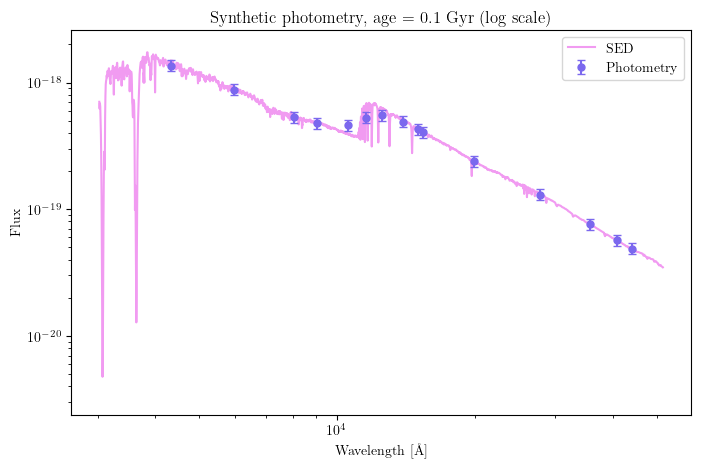

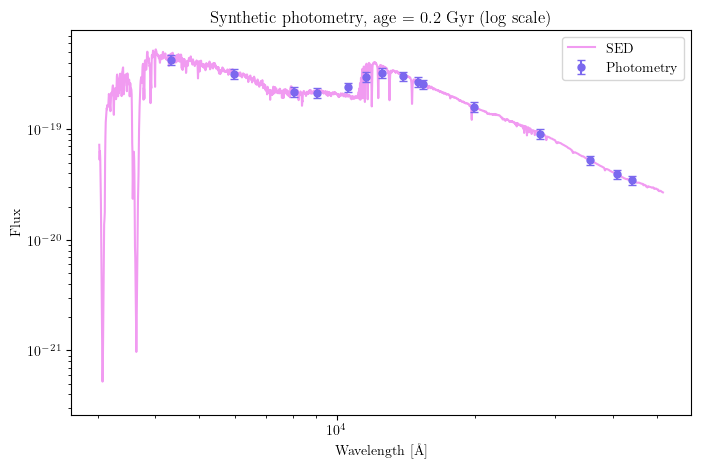

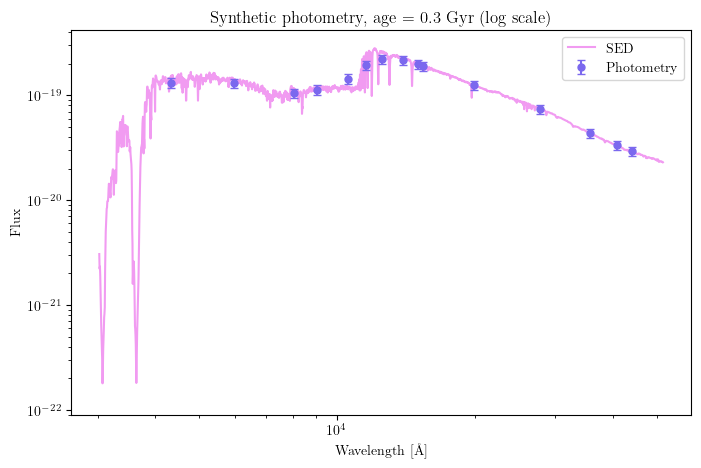

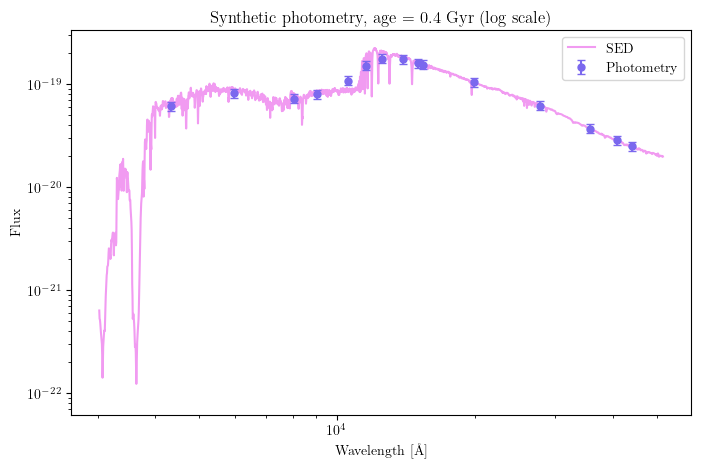

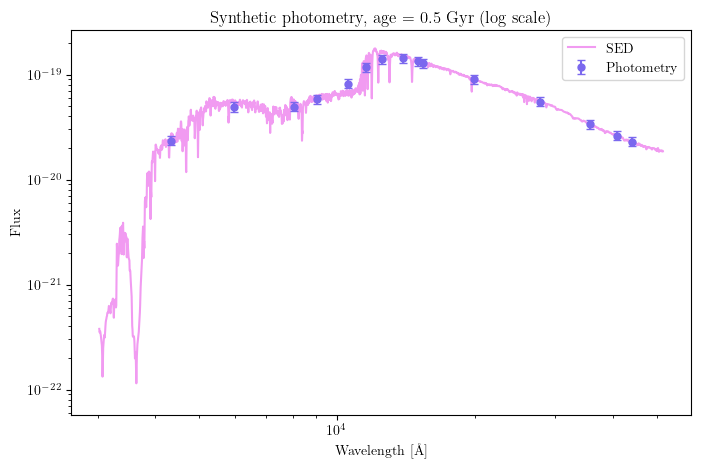

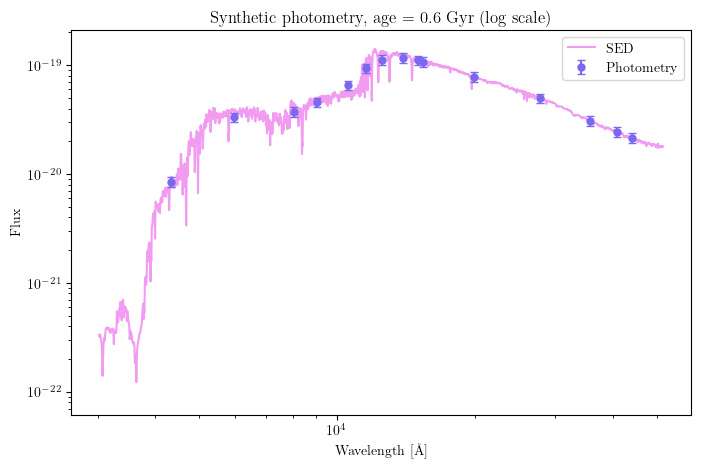

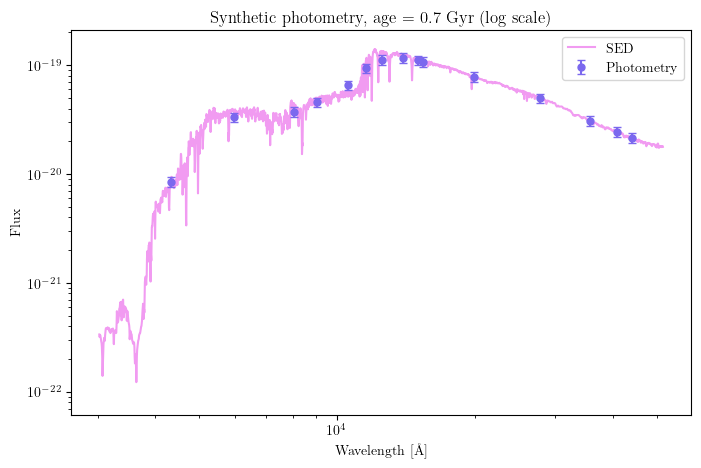

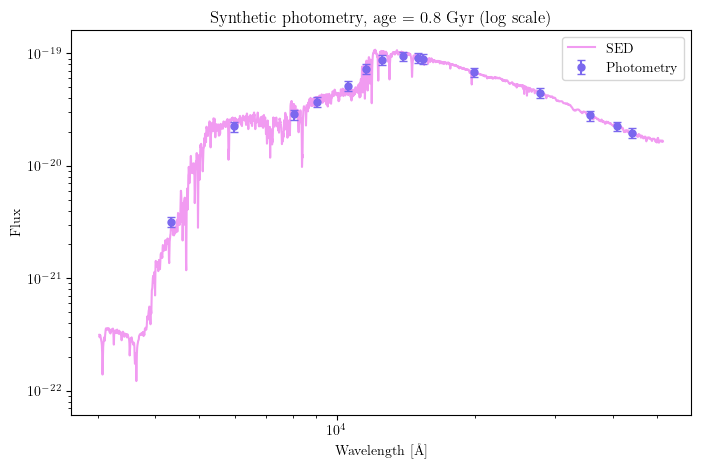

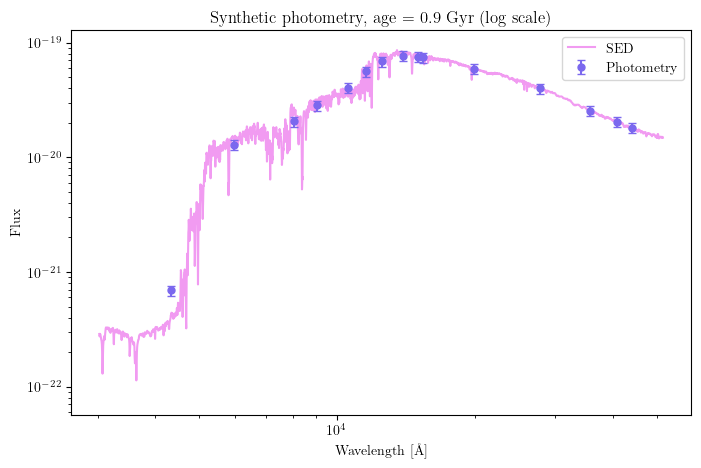

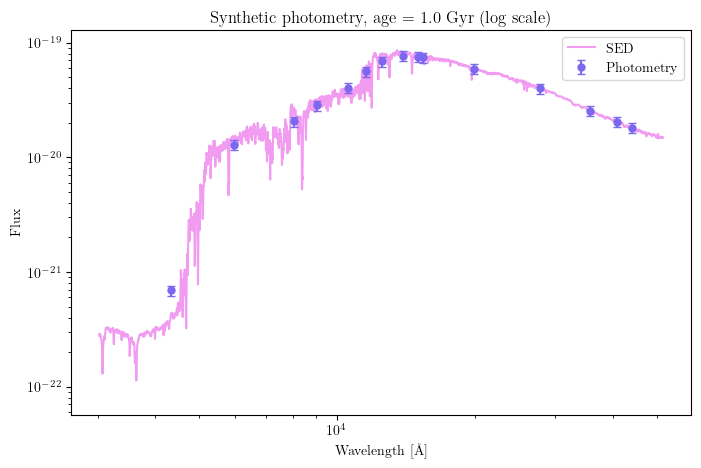

In [7]:

for t in years:

    burst = {
        "age": t,
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 2,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }
    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
       spec_wavs = np.arange(global_min - 500,
                      global_max + 500,
                      5.)

    )

    # synthetic photometry
    photometry = model.photometry 
    fluxes = np.array(photometry)

    fluxes_error = fluxes / 10.0

    filter_wavelengths = []

    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:,0]
        transmission = filt_data[:,1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        filter_wavelengths.append(eff_wave)

    filter_wavelengths = np.array(filter_wavelengths)
    photometry = np.array(model.photometry)  # flux in each filter
    y = model.spectrum

    plt.figure(figsize=(8,5))
    plt.errorbar(filter_wavelengths, fluxes, yerr=fluxes_error, fmt='o', ms=5, color='mediumslateblue', elinewidth=1.5, capsize=3, label='Photometry', zorder=5)
    plt.plot(model.spectrum[:,0], model.spectrum[:,1],
         alpha=0.8, color='violet', label='SED', zorder=1)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Flux")
    plt.title(f"Synthetic photometry, age = {t} Gyr (log scale)")
    plt.ylim(y[:,1].min()*0.5, y[:,1].max()*1.5)
    plt.legend()
    plt.show()

In [12]:
for t in years:

    burst = {
        "age": t,
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 2,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500,
                            global_max + 500,
                            5.),
    )

    flux_lambda = np.array(model.photometry)   # erg/s/cm^2/Å

    # effective wavelengths in Å
    filter_wavelengths = []

    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:,0]
        transmission = filt_data[:,1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        filter_wavelengths.append(eff_wave)

    filter_wavelengths = np.array(filter_wavelengths)

# Convert F_lambda → F_nu (µJy)
c = 2.99792458e18  # speed of light in Å/s

flux_nu = flux_lambda * (filter_wavelengths**2) / c
flux_nu = flux_nu / 1e-23      # convert to Jy
flux_nu = flux_nu * 1e6        # Jy → µJy

fluxes = flux_nu
fluxes_error = fluxes / 10.0

In [13]:
print("min flux =", fluxes.min())
print("max flux =", fluxes.max())

min flux = 0.00043418382920601655
max flux = 1.175052793606768


In [10]:
for t in years:

    burst = {
        "age": t,
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components = {
        "redshift": 2,
        "burst": burst,
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }

    model = pipes.model_galaxy(
        model_components,
        filt_list=filter_files,
        spec_wavs=np.arange(global_min - 500,
                            global_max + 500,
                            5.),
    )

    flux_lambda = np.array(model.photometry)   # erg/s/cm^2/Å

    # effective wavelengths in Å
    filter_wavelengths = []

    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:,0]
        transmission = filt_data[:,1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        filter_wavelengths.append(eff_wave)

    filter_wavelengths = np.array(filter_wavelengths)

    # Convert F_lambda -> F_nu (µJy)
    c = 2.99792458e18  # speed of light in Å/s

    flux_nu = flux_lambda * (filter_wavelengths**2) / c
    flux_nu = flux_nu / 1e-23      # convert to Jy
    flux_nu = flux_nu * 1e6        # Jy -> µJy

    fluxes = flux_nu
    fluxes_error = fluxes / 10.0

    galaxy_photometry = np.c_[fluxes, fluxes_error]

    def load_synthetic(ID):
        return galaxy_photometry

    galaxy = pipes.galaxy(
        f"age_{t:.2f}Gyr",
        load_synthetic,
        spectrum_exists=False,
        photometry_exists=True,
        filt_list=filter_files
    )

    fit_info = {
        "redshift": 2.0,
        "exponential": {
            "massformed": (5., 12.),
            "metallicity": (0.0001, 2.),
            "metallicity_prior": "log_10",
            "age": (0.001, 1.0),
            "tau": (0.001, 5.)
        },
        "dust": {
            "type": "Calzetti",
            "Av": (0., 2.),
        },
        "nebular": {
            "logU": (-4., -2.)
        }
    }

    fit = pipes.fit(galaxy, fit_info)
    fit.fit(verbose=True)

    print(f"Finished fitting age {t} Gyr")

MultiNest not available. Switching to nautilus.

Bagpipes: fitting object age_0.00Gyr

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 33     | 1        | 4        | 17700    | N/A    | 3443  | +592.44  

Completed in 6282.0 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
dust:Av                        0.372      0.415      0.464
exponential:age                0.001      0.002      0.003
exponential:massformed         9.981     10.006     10.028
exponential:metallicity        0.361      0.477      0.611
exponential:tau                0.776      2.521      4.169
nebular:logU                  -3.059     -2.961     -2.843


Finished fitting age 0.0 Gyr
MultiNest not available. Switching to nautilus.

Bagpipes: fitting obj

### Posterior information

Calculated derived properties:

In [16]:
fit.posterior.get_advanced_quantities()
list(fit.posterior.samples)

['dust:Av',
 'exponential:age',
 'exponential:massformed',
 'exponential:metallicity',
 'exponential:tau',
 'nebular:logU',
 'stellar_mass',
 'formed_mass',
 'sfr',
 'ssfr',
 'nsfr',
 'mass_weighted_age',
 'tform',
 'tquench',
 'mass_weighted_zmet',
 'sfh',
 'photometry',
 'spectrum_full',
 'uvj',
 'chisq_phot',
 'dust_curve']

Posterior median living stellar mass:

In [17]:
print(np.median(fit.posterior.samples["stellar_mass"]))

9.765622365357984


Posterior specific median SFR:

In [18]:
print(np.median(np.log10(fit.posterior.samples["sfr"]) - fit.posterior.samples["stellar_mass"]))

-21.019230006594142


C:\Users\Abigail Crowther\AppData\Local\Temp\ipykernel_30376\1765300411.py:1: RuntimeWarning: divide by zero encountered in log10
  print(np.median(np.log10(fit.posterior.samples["sfr"]) - fit.posterior.samples["stellar_mass"]))


Confidence interval on mass-weighted age:

In [19]:
print(np.percentile(fit.posterior.samples["mass_weighted_age"], (16, 84)))

[0.76805047 0.9597021 ]


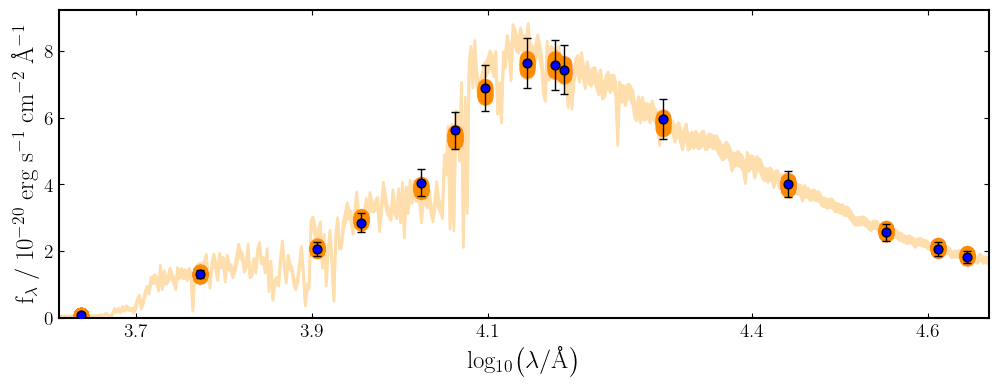

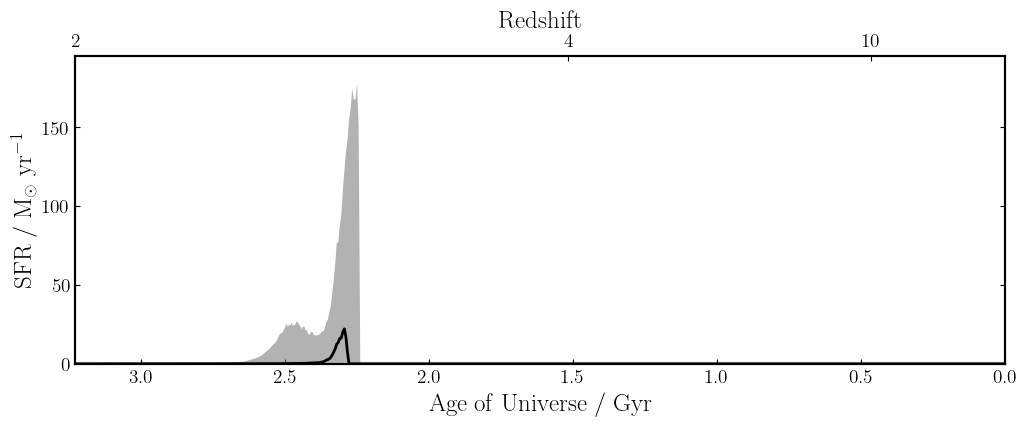

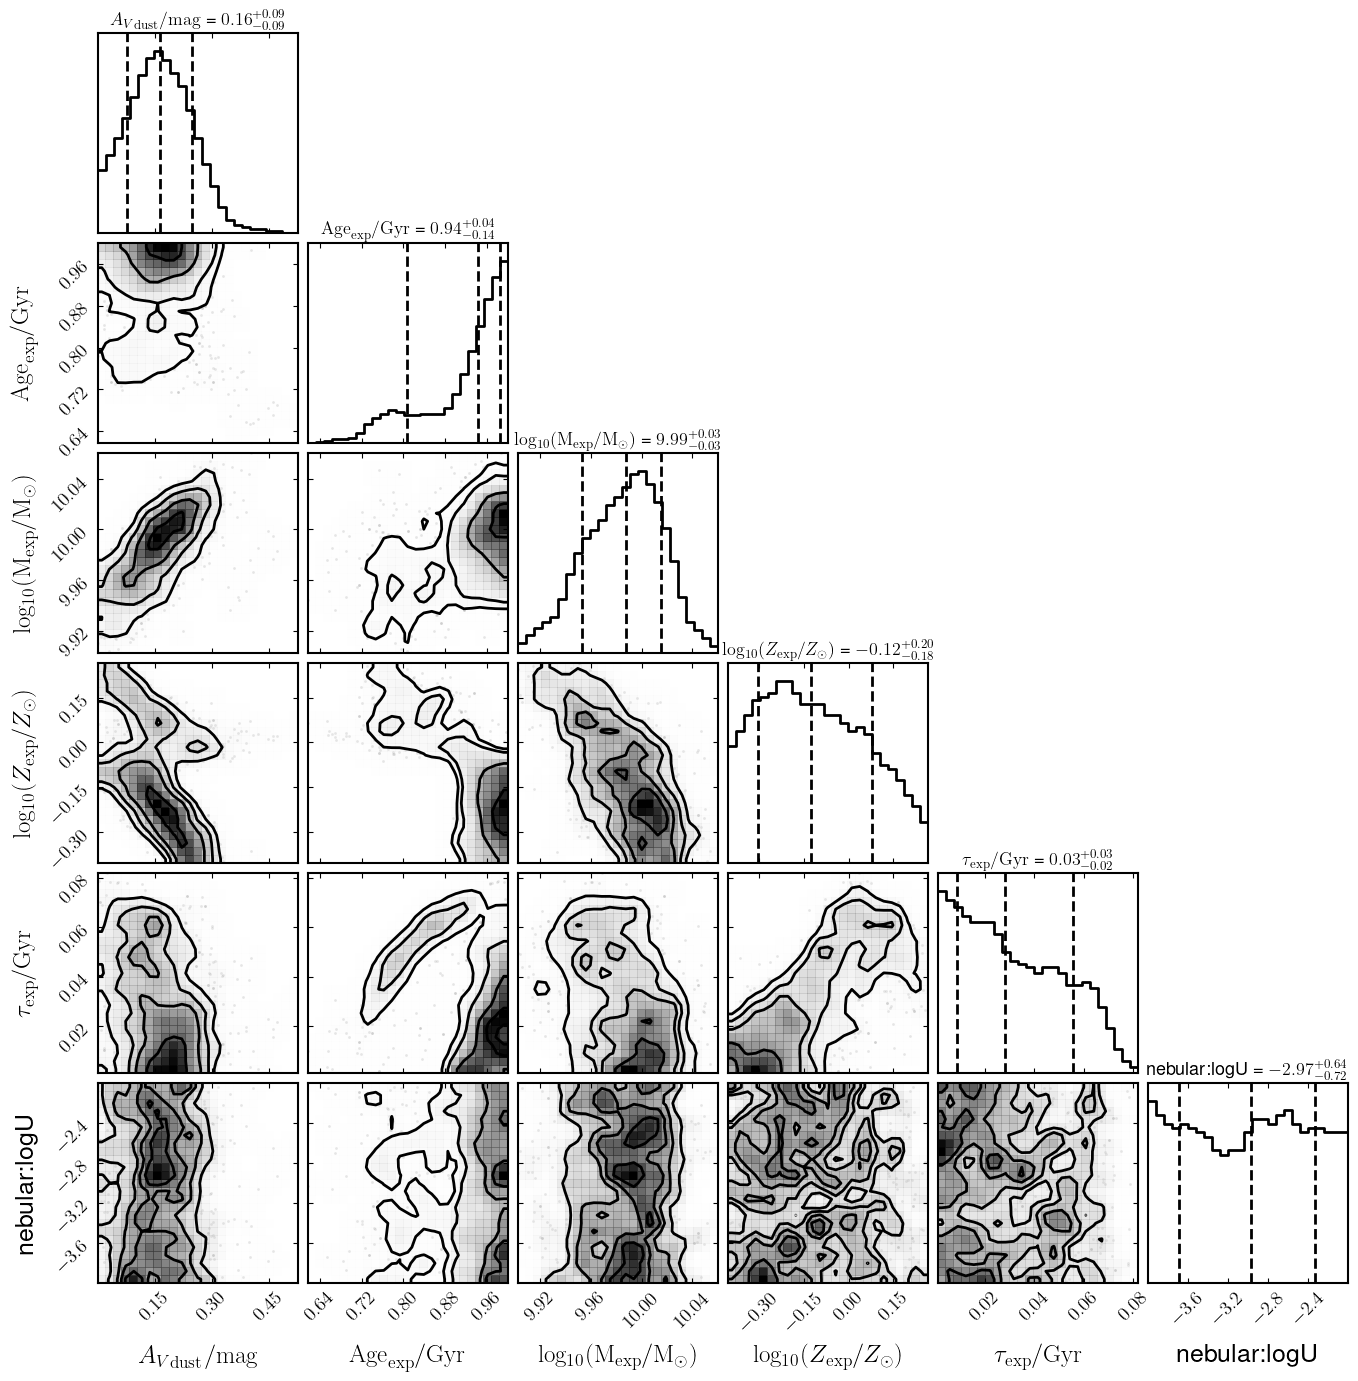

In [26]:
fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)
fig = fit.plot_corner(save=False, show=True)